In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
df = pd.read_csv("../data/processed/df_final_poblacion.csv")

In [12]:
df[df["Municipio"] == "Barcelona"]["Poblacion"].unique()


<StringArray>
['1608746', '5542680', '1620809', '5576037', '1620343', '5609350', '1636762',
 '5664579', '1664182', '5743402', '1636732', '5714730', '1636193', '5727615',
 '1660122', '5805500', '1702547', '5899063', '1731649', '5983325']
Length: 20, dtype: str

In [13]:
df["Poblacion"] = df["Poblacion"].str.replace(",", "")
df = df[df["Poblacion"].astype(int) < 3000000]
df[df["Municipio"] == "Barcelona"]

,Municipio,Delitos,Año,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion
5028,Barcelona,Daños,2016,Enero-Marzo,1,Barcelona,2252,2252.0,1608746
5030,Barcelona,Daños,2016,Enero-Junio,2,Barcelona,4619,2367.0,1608746
5032,Barcelona,Daños,2016,Enero-Septiembre,3,Barcelona,6992,2373.0,1608746
5034,Barcelona,Daños,2016,Enero-Diciembre,4,Barcelona,9155,2163.0,1608746
5036,Barcelona,Delitos Sexuales,2017,Enero-Marzo,1,Barcelona,180,180.0,1620809
...,...,...,...,...,...,...,...,...,...
5664,Barcelona,Trafico De Drogas,2024,Enero-Septiembre,3,Barcelona,1410,452.0,1702547
5666,Barcelona,Trafico De Drogas,2024,Enero-Diciembre,4,Barcelona,1887,477.0,1702547
5668,Barcelona,Trafico De Drogas,2025,Enero-Marzo,1,Barcelona,572,572.0,1731649
5670,Barcelona,Trafico De Drogas,2025,Enero-Junio,2,Barcelona,1210,638.0,1731649


### Construccion fecha

In [14]:
trimestre_fecha = {
    1:"03-31",
    2:"06-30",
    3:"09-30",
    4:"12-31"
} 
df["fecha_str"] = df.apply(lambda fila: f"{fila["Año"]}-{trimestre_fecha[fila["Trimestre"]]}", axis=1)

df["fecha"] = pd.to_datetime(df["fecha_str"])


In [15]:
df[(df["Año"].isin([2016,2017])) & (df["Total"] > 2000)]

,Municipio,Delitos,Año,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion,fecha_str,fecha
418,Alcalá de Henares,Hurtos,2016,Enero-Septiembre,3,Madrid,2138,678.0,195907,2016-09-30,2016-09-30
419,Alcalá de Henares,Hurtos,2016,Enero-Diciembre,4,Madrid,2801,663.0,195907,2016-12-31,2016-12-31
422,Alcalá de Henares,Hurtos,2017,Enero-Septiembre,3,Madrid,2078,663.0,194310,2017-09-30,2017-09-30
423,Alcalá de Henares,Hurtos,2017,Enero-Diciembre,4,Madrid,2676,598.0,194310,2017-12-31,2017-12-31
1065,Alcorcón,Hurtos,2016,Enero-Diciembre,4,Madrid,2469,675.0,167354,2016-12-31,2016-12-31
...,...,...,...,...,...,...,...,...,...,...,...
33136,Valencia,Hurtos,2017,Enero-Marzo,1,Valencia,5025,5025.0,2540707,2017-03-31,2017-03-31
33137,Valencia,Hurtos,2017,Enero-Septiembre,3,Valencia,14205,9180.0,2540707,2017-09-30,2017-09-30
33138,Valencia,Hurtos,2017,Enero-Diciembre,4,Valencia,18624,4419.0,2540707,2017-12-31,2017-12-31
33201,Valencia,Robos Con Fuerza,2017,Enero-Septiembre,3,Valencia,3259,2349.0,2540707,2017-09-30,2017-09-30


### Convertir fecha a indice

In [16]:
df = df.sort_values("fecha")
df = df.set_index("fecha")
df = df.copy()

### Eliminar columnas que ya no aportan

In [17]:
df = df.drop(columns=["Año","Periodo Trimestral","Trimestre","fecha_str"])
df = df[df.index.year != 2025]
df

,Municipio,Delitos,Provincia,Total,Valor trimestral,Poblacion
fecha,,,,,,
2016-03-31,Gandia,Hurtos,Valencia,323,323.0,74814
2016-03-31,Manresa,Daños,Barcelona,87,87.0,74752
2016-03-31,Valencia,Hurtos,Valencia,5132,5132.0,2544264
2016-03-31,Torrent,Hurtos,Valencia,227,227.0,80762
2016-03-31,Castelldefels,Hurtos,Barcelona,207,207.0,64892
...,...,...,...,...,...,...
2024-12-31,Sant Joan Despí,Trafico De Drogas,Barcelona,5,2.0,35083
2024-12-31,Alfafar,Robos Con Fuerza,Valencia,84,28.0,22131
2024-12-31,Sant Quirze del Vallès,Secuestro,Barcelona,0,0.0,20161


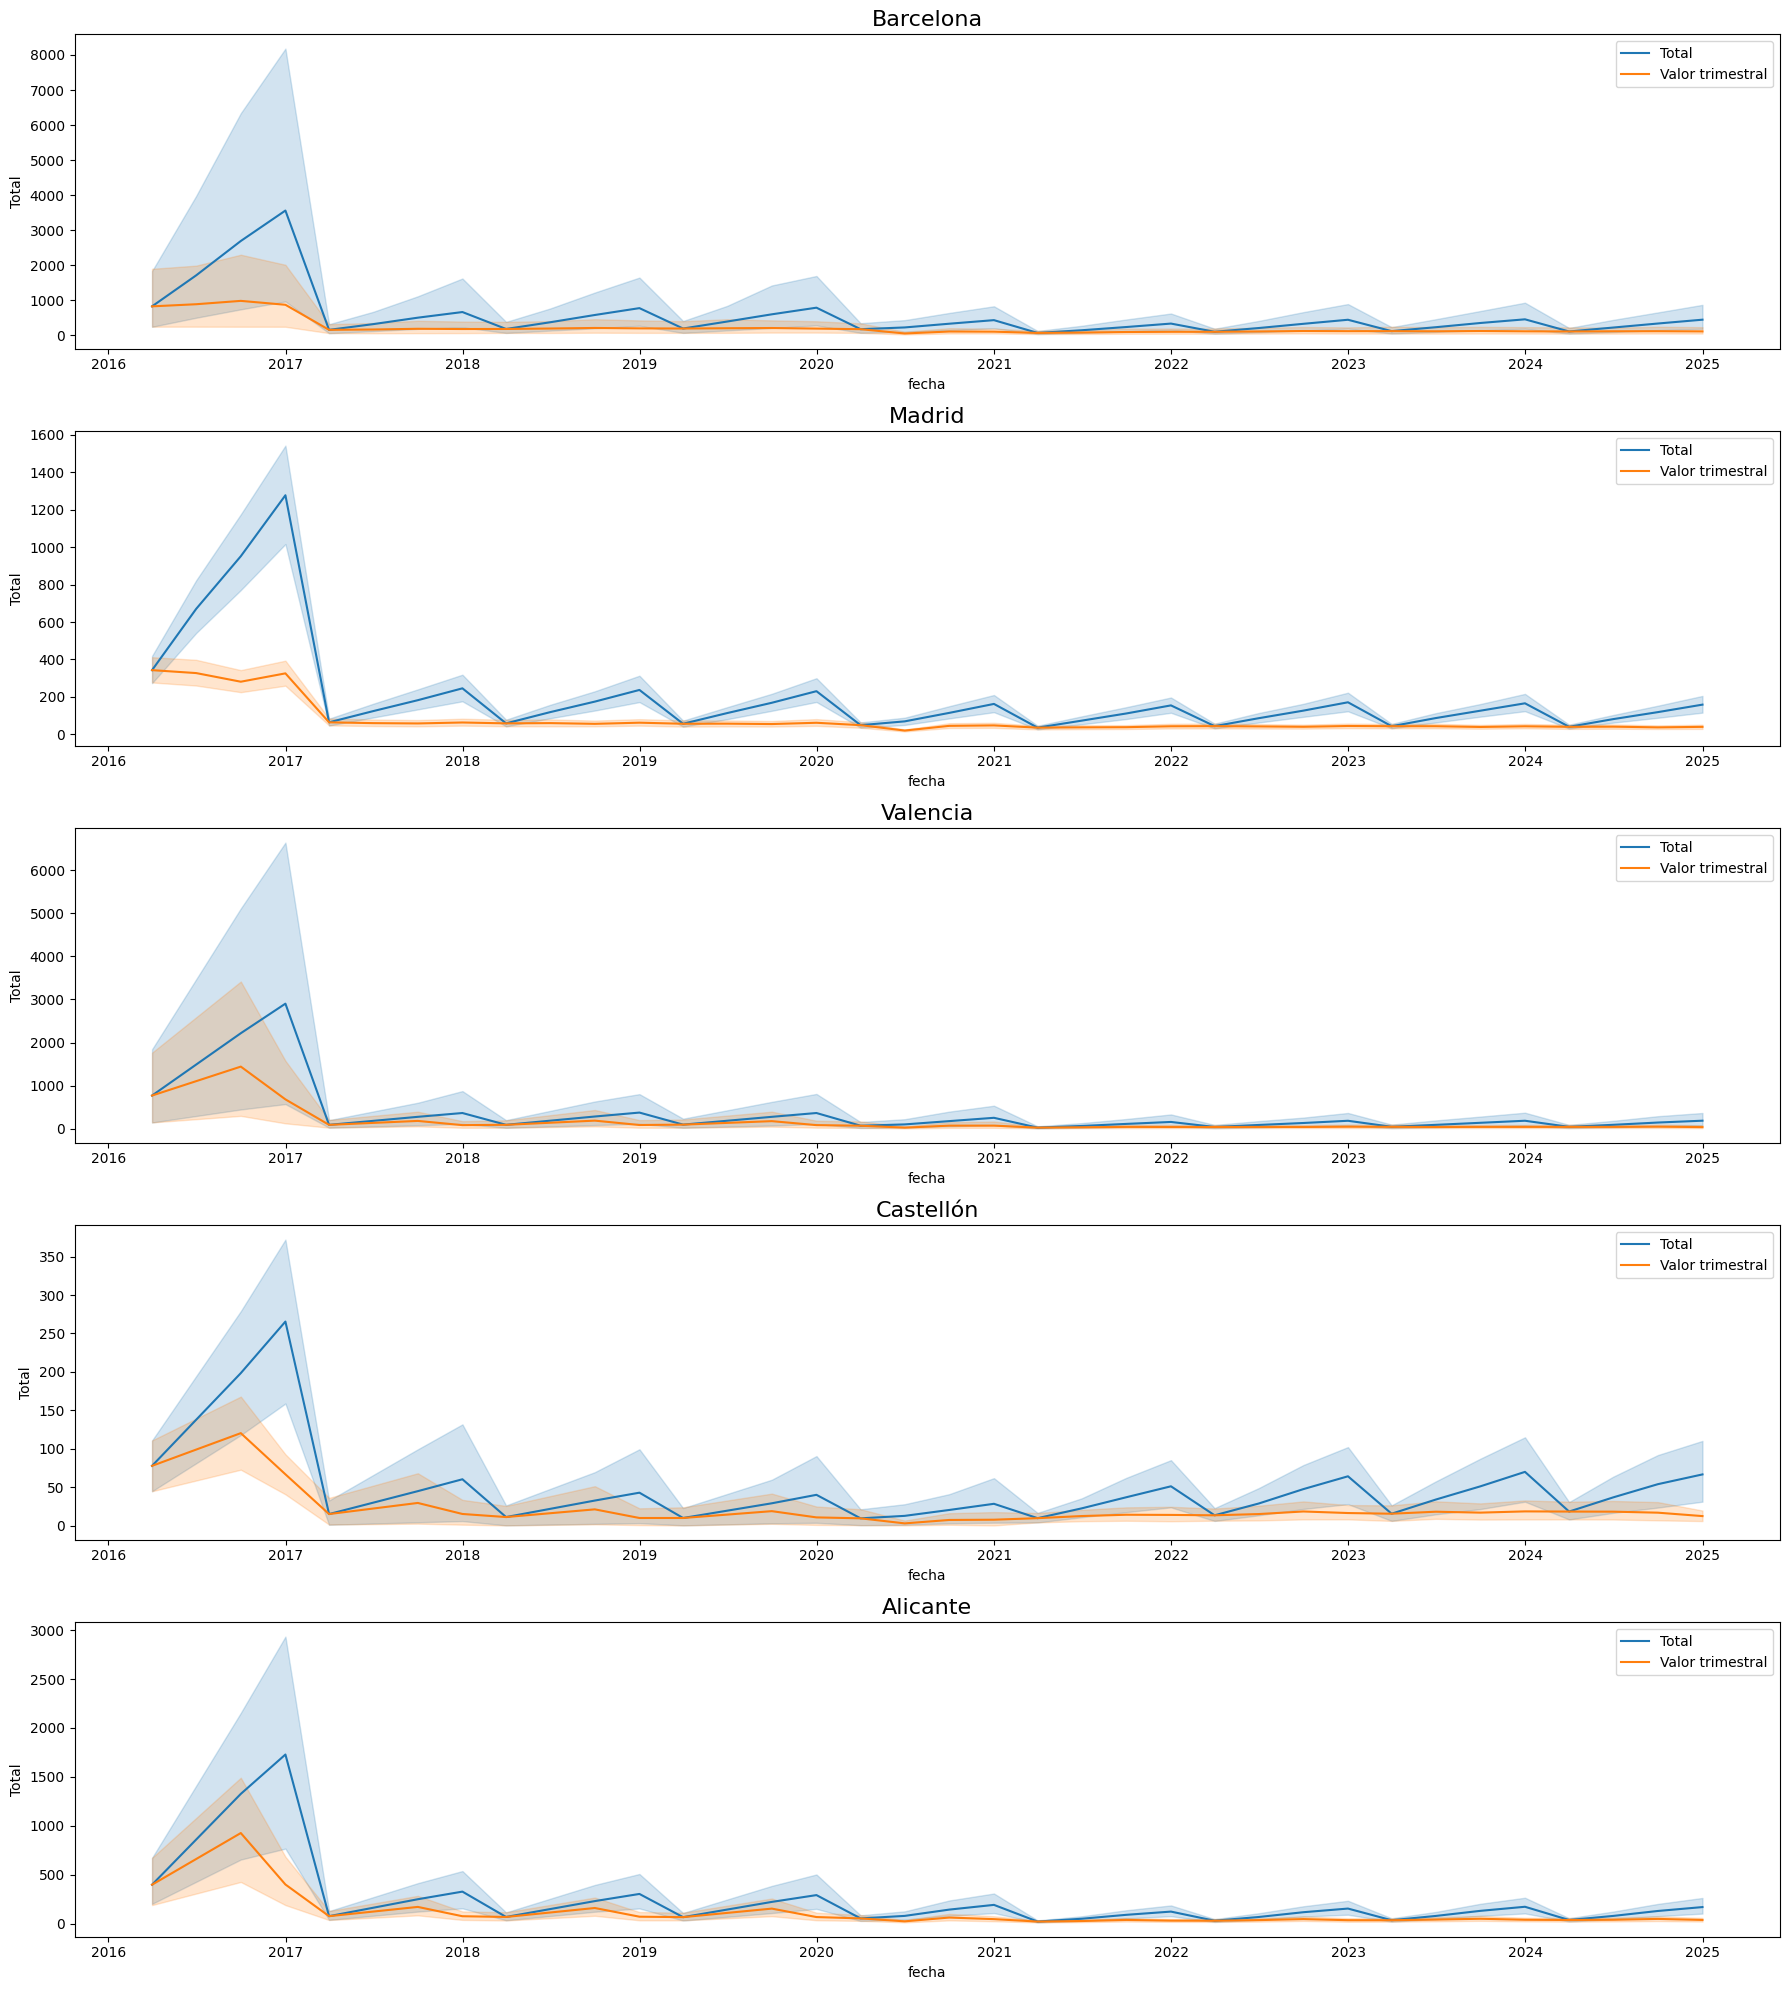

In [18]:
# Filtrado por provincia
barcelona = df[df["Provincia"] == "Barcelona"]
madrid = df[df["Provincia"] == "Madrid"]
valencia = df[df["Provincia"] == "Valencia"]
castellon = df[df["Provincia"] == "Castellón"]
alicante = df[df["Provincia"] == "Alicante"]

# Lista de dataframes y nombres
dfs = [barcelona, madrid, valencia, castellon, alicante]
nombres = ["Barcelona", "Madrid", "Valencia", "Castellón", "Alicante"]

# Crear panel vertical
fig, axes = plt.subplots(5, 1, figsize=(18, 20))

for ax, data, nombre in zip(axes, dfs, nombres):
    sns.lineplot(data=data, x=data.index, y="Total", ax=ax, label="Total")
    sns.lineplot(data=data, x=data.index, y="Valor trimestral", ax=ax, label="Valor trimestral")
    ax.set_title(nombre, fontsize=16)
    ax.legend()

plt.tight_layout()
plt.show()


### Conclusiones
-Tendencia: disminuye sutilmente con  el tipo
-Outliers?: Observamos un pico anomalo entre 2016-2017 con una caida a finales de 2017